# B4T1 - Diseño de Redes Confiables
## Parte 2: Aprendizaje Justo (FAIR Loss)

Implementación de una **función de coste customizada** que combina el error de
clasificación (BCE) con una **penalización por dependencia estadística** entre la
predicción del modelo y la **variable sensible** (género, `CODE_GENDER`):

$$\mathcal{L}_{FAIR} = \text{BCE}(y, \hat{y}) \;+\; \lambda \cdot \big|\,\rho_{Pearson}(\hat{y},\, s)\,\big|$$

donde `s` es el género (M=0, F=1) y `λ ≥ 0` pondera la justicia. Medimos el
**trade-off precisión × justicia** mediante un *sweep* manual de `λ` y con
**Keras Tuner**, y comparamos el modelo Base (`λ=0`) frente al mejor modelo FAIR.

## 0. Setup y semillas

Fijamos las semillas (`random`, `numpy`, `tensorflow`/`keras`) para que el
notebook sea reproducible con *Run All*.

In [1]:
import os, sys, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import keras
from keras import ops
import tensorflow as tf
keras.utils.set_random_seed(SEED)

print("Keras:", keras.__version__, "| backend:", keras.backend.backend())

Keras: 3.12.2 | backend: tensorflow


## 1. Import del módulo base (`src/base.py`)

Importamos exactamente el mismo loader, capa customizada y constructor de modelo
que usa el `01_base_model.ipynb`. Así la comparación **Base vs FAIR** es justa
(misma arquitectura, mismo preprocesado).

In [2]:
# Raíz del repo (este notebook vive en notebooks/)
ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.base import (
    load_home_credit_data, RatioEndeudamientoLayer, build_model,
    compute_class_weight_balanced, FEATURE_NAMES, IDX_GENDER,
)

DATA_PATH = os.path.join(ROOT, "data", "application_train.csv")
OUTPUTS = os.path.join(ROOT, "outputs")
os.makedirs(OUTPUTS, exist_ok=True)

print("Features de entrada:", FEATURE_NAMES)
print("Índice de la variable sensible (CODE_GENDER) dentro de X:", IDX_GENDER)

Features de entrada: ['CODE_GENDER', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1_NULL', 'EXT_SOURCE_2_NULL', 'EXT_SOURCE_3_NULL']
Índice de la variable sensible (CODE_GENDER) dentro de X: 0


### Nota sobre la variable sensible dentro de `X`

El loader deja `CODE_GENDER` **como columna de entrada** del modelo (índice 0),
además de devolverla por separado como `s`. Mantenemos esa configuración
(*default*) para no desplazar los índices que usa la capa customizada y para
preservar la comparación *apples-to-apples* con el modelo base. La FAIR loss
sirve precisamente para **suprimir la influencia** del género en la predicción.

<!--
ALTERNATIVA (NO ejecutada): "fairness through unawareness".
Para excluir CODE_GENDER de las features habría que:
  1) eliminar la columna 0 de X_train/X_test (y reajustar el scaler),
  2) aplicar el MISMO cambio en 01_base_model.ipynb,
  3) verificar que RatioEndeudamientoLayer usa los nuevos índices
     (income/credit/annuity se desplazarían en -1).
Se deja documentado pero no se implementa sin confirmación.
-->

In [3]:
(X_train, y_train, s_train), (X_test, y_test, s_test) = load_home_credit_data(DATA_PATH)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Tasa de impago (train): {np.mean(y_train):.3f}")
print(f"Proporción mujeres (s=1) en train: {np.mean(s_train):.3f}")

X_train: (246005, 11) | X_test: (61502, 11)
Tasa de impago (train): 0.081
Proporción mujeres (s=1) en train: 0.658


## 2. Conjunto de validación y formato `y = (N, 2)`

**(a) Validación**: el loader solo devuelve train/test. Recortamos un conjunto de
validación *desde dentro del train* (15%, estratificado). **El test queda intocado**
hasta la evaluación final.

**(b) Empaquetado de la variable sensible**: una loss de Keras solo recibe
`(y_true, y_pred)`. Para poder pasar `s` a la loss, construimos las etiquetas con
forma `(N, 2)`:

| columna | contenido |
|---|---|
| `y[:, 0]` | **target** (0/1) → término BCE |
| `y[:, 1]` | **sensible** `s` (género) → término de correlación |

In [4]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val, s_tr, s_val = train_test_split(
    X_train, y_train, s_train, test_size=0.15, random_state=42, stratify=y_train
)

def stack_target_sensitive(y, s):
    """Construye etiquetas (N, 2) = [target, sensible]."""
    return np.column_stack([np.asarray(y), np.asarray(s)]).astype("float32")

y_tr2  = stack_target_sensitive(y_tr,  s_tr)
y_val2 = stack_target_sensitive(y_val, s_val)
y_te2  = stack_target_sensitive(y_test, s_test)

# class_weight balanceado (dataset ~8% positivos) -> lo aplicamos DENTRO de la loss
cw = compute_class_weight_balanced(y_tr)
W_NEG, W_POS = cw[0], cw[1]

print("X_tr:", X_tr.shape, "| X_val:", X_val.shape)
print("y_tr2:", y_tr2.shape, "(col0=target, col1=sensible)")
print(f"class_weight -> neg(0): {W_NEG:.3f} | pos(1): {W_POS:.3f}")

X_tr: (209104, 11) | X_val: (36901, 11)
y_tr2: (209104, 2) (col0=target, col1=sensible)
class_weight -> neg(0): 0.544 | pos(1): 6.193


## 3. FAIR Loss + tests de sanidad

### 3.1 Correlación de Pearson diferenciable (a mano, con `keras.ops`)

Implementamos Pearson **solo con operaciones de tensor** (diferenciable, sin
`scipy`/`numpy` dentro). Sumamos `epsilon=1e-8` al denominador (estabilidad) y
tomamos el **valor absoluto** (queremos ≈0; el signo es irrelevante).

In [5]:
EPS = 1e-8

def pearson_abs(p, s, eps=EPS):
    """|corr_Pearson(p, s)| diferenciable, solo con keras.ops."""
    p = ops.cast(ops.reshape(p, (-1,)), "float32")
    s = ops.cast(ops.reshape(s, (-1,)), "float32")
    pm = p - ops.mean(p)
    sm = s - ops.mean(s)
    num = ops.sum(pm * sm)
    den = ops.sqrt(ops.sum(pm ** 2) * ops.sum(sm ** 2)) + eps
    return ops.abs(num / den)

# TODO (mejoras futuras, NO implementadas ahora):
#   * Spearman: aplicar pearson_abs sobre los RANGOS de p y s (rangos
#     diferenciables vía soft-ranking, p.ej. softrank).
#   * Diferencia de Paridad Demográfica diferenciable:
#       |mean(p[s==1]) - mean(p[s==0])|  con máscaras suaves (sigmoide sobre s).

### 3.2 Test de sanidad: nuestra Pearson vs `scipy.stats.pearsonr`

Comparamos en vectores aleatorios fijos. **Solo se continúa si pasa** (tol ~1e-5).

In [6]:
from scipy.stats import pearsonr

rng = np.random.default_rng(0)
for k in range(3):
    a = rng.normal(size=300).astype("float32")
    b = (0.4 * a + rng.normal(size=300)).astype("float32")
    mine = float(pearson_abs(ops.convert_to_tensor(a), ops.convert_to_tensor(b)))
    ref = abs(pearsonr(a, b)[0])
    diff = abs(mine - ref)
    print(f"caso {k}: mine={mine:.7f}  scipy={ref:.7f}  diff={diff:.2e}")
    assert diff < 1e-5, "FALLA el test de sanidad de Pearson"
print("\n✓ Test de sanidad SUPERADO: la Pearson diferenciable coincide con scipy.")

caso 0: mine=0.4180103  scipy=0.4180102  diff=8.94e-08
caso 1: mine=0.3732103  scipy=0.3732103  diff=0.00e+00
caso 2: mine=0.3967791  scipy=0.3967791  diff=0.00e+00

✓ Test de sanidad SUPERADO: la Pearson diferenciable coincide con scipy.


### 3.3 Factory de la FAIR Loss

`make_fair_loss(lambda_fair, base_error="bce")` devuelve una loss lista para
`model.compile`. Desempaqueta `y_true (N,2)` → col 0 = target (BCE/MSE), col 1 =
sensible (correlación). El `class_weight` balanceado se aplica **dentro** del
término base (porque `y_true` es 2D y el `class_weight` de Keras no encaja con ese
formato). Soporta `base_error="mse"` como flag (visto en clase).

In [7]:
def make_fair_loss(lambda_fair, base_error="bce", w_neg=1.0, w_pos=1.0, eps=EPS):
    """Factory de la FAIR loss: BCE/MSE ponderado + lambda * |corr(yhat, s)|.

    y_true tiene forma (N, 2): col 0 = target, col 1 = variable sensible.
    """
    lambda_fair = float(lambda_fair)
    assert base_error in ("bce", "mse")

    def fair_loss(y_true, y_pred):
        y = y_true[:, 0:1]      # target
        s = y_true[:, 1:2]      # sensible
        y_pred = ops.clip(y_pred, 1e-7, 1.0 - 1e-7)

        if base_error == "bce":
            per_sample = keras.losses.binary_crossentropy(y, y_pred)     # (N,)
        else:
            per_sample = ops.mean(ops.square(y - y_pred), axis=-1)       # (N,)

        # class_weight balanceado aplicado por muestra
        w = y[:, 0] * w_pos + (1.0 - y[:, 0]) * w_neg
        base = ops.sum(w * per_sample) / (ops.sum(w) + eps)

        # penalización de justicia
        corr = pearson_abs(y_pred, s, eps)
        return base + lambda_fair * corr

    fair_loss.__name__ = f"fair_loss_lambda_{lambda_fair:g}"
    return fair_loss

### 3.4 Métrica de justicia por época + métrica de AUC

`FairCorr` reporta `|corr(ŷ, s)|` **exacto por época** (acumuladores tipo
*streaming*, no media de batches). `TargetAUC` es el AUC sobre la columna *target*
de `y_true (N,2)` — lo usamos como objetivo del Keras Tuner (`val_auc`).

In [8]:
class FairCorr(keras.metrics.Metric):
    """|corr(yhat, s)| exacto por época mediante acumuladores."""
    def __init__(self, name="fair_corr", eps=EPS, **kw):
        super().__init__(name=name, **kw)
        self.eps = eps
        self.n   = self.add_weight(name="n",   initializer="zeros")
        self.sp  = self.add_weight(name="sp",  initializer="zeros")
        self.ss  = self.add_weight(name="ss",  initializer="zeros")
        self.spp = self.add_weight(name="spp", initializer="zeros")
        self.sss = self.add_weight(name="sss", initializer="zeros")
        self.sps = self.add_weight(name="sps", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        p = ops.reshape(ops.cast(y_pred, "float32"), (-1,))
        s = ops.reshape(ops.cast(y_true[:, 1:2], "float32"), (-1,))
        self.n.assign_add(ops.cast(ops.size(p), "float32"))
        self.sp.assign_add(ops.sum(p));      self.ss.assign_add(ops.sum(s))
        self.spp.assign_add(ops.sum(p * p)); self.sss.assign_add(ops.sum(s * s))
        self.sps.assign_add(ops.sum(p * s))

    def result(self):
        n = self.n
        cov = n * self.sps - self.sp * self.ss
        vp  = n * self.spp - self.sp ** 2
        vs  = n * self.sss - self.ss ** 2
        return ops.abs(cov / (ops.sqrt(vp * vs) + self.eps))

    def reset_state(self):
        for v in self.variables:
            v.assign(0.0)


class TargetAUC(keras.metrics.AUC):
    """AUC sobre la columna target (col 0) de y_true (N, 2)."""
    def update_state(self, y_true, y_pred, sample_weight=None):
        return super().update_state(y_true[:, 0:1], y_pred, sample_weight)

### 3.5 Utilidades de evaluación en test

`evaluate_test` calcula, sobre el conjunto de test (limиар 0.5), todas las
métricas del trabajo: **Accuracy, ROC-AUC, PR-AUC**, dependencia FAIR
`|corr(ŷ, s)|` y **Demographic Parity Difference** = `|P(ŷ=1|s=0) − P(ŷ=1|s=1)|`
(umbral 0.5). (Recordatorio: M=0, F=1.)

In [9]:
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

def demographic_parity_diff(y_pred, s, thr=0.5):
    yhat = (np.asarray(y_pred).ravel() >= thr).astype(int)
    s = np.asarray(s).ravel()
    p_s0 = yhat[s == 0].mean()   # hombres
    p_s1 = yhat[s == 1].mean()   # mujeres
    return abs(p_s0 - p_s1)

def evaluate_test(model, X, y_true, s, thr=0.5):
    p = model.predict(X, verbose=0, batch_size=4096).ravel()
    y_true = np.asarray(y_true).ravel()
    return {
        "accuracy": accuracy_score(y_true, (p >= thr).astype(int)),
        "roc_auc": roc_auc_score(y_true, p),
        "pr_auc": average_precision_score(y_true, p),
        "fair_corr": abs(np.corrcoef(p, np.asarray(s).ravel())[0, 1]),
        "dpd": demographic_parity_diff(p, s, thr),
    }

def train_one(lambda_fair, units1=64, epochs=40, patience=10, verbose=0):
    """Entrena un modelo (misma arquitectura base + capa custom) con FAIR loss."""
    keras.utils.set_random_seed(SEED)
    model = build_model(X_tr.shape[1], units1=units1)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=make_fair_loss(lambda_fair, "bce", W_NEG, W_POS),
        metrics=[TargetAUC(name="auc"), FairCorr()],
    )
    es = keras.callbacks.EarlyStopping(
        monitor="val_auc", patience=patience, mode="max", restore_best_weights=True)
    hist = model.fit(
        X_tr, y_tr2, validation_data=(X_val, y_val2),
        epochs=epochs, batch_size=512, verbose=verbose, callbacks=[es],
    )
    return model, hist

## 4. Experimento A — *Sweep* manual de `λ`

Entrenamos un modelo por cada `λ ∈ {0, 0.5, 1, 2, 5, 10, 20, 50}` (con `λ=0` = modelo
**Base**), con *early stopping* sobre `val_auc` (mismo criterio que el 01: `patience=10`, `mode=max`), semillas fijas, `class_weight`
balanceado y la **misma arquitectura + capa customizada**. Registramos en **test**:
Accuracy, ROC-AUC, PR-AUC, `|corr(ŷ, s)|` y DPD.

In [10]:
LAMBDAS = [0.0, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]

sweep_rows = []
histories = {}      # guardamos curvas de loss para los entregables
models = {}

t0 = time.time()
for lam in LAMBDAS:
    model, hist = train_one(lam, epochs=40, patience=10)
    res = evaluate_test(model, X_test, y_test, s_test)
    res["lambda"] = lam
    res["epochs"] = len(hist.history["loss"])
    sweep_rows.append(res)
    histories[lam] = hist.history
    models[lam] = model
    print(f"λ={lam:<5}  ep={res['epochs']:<2}  "
          f"AUC={res['roc_auc']:.4f}  PR={res['pr_auc']:.4f}  "
          f"acc={res['accuracy']:.4f}  |corr|={res['fair_corr']:.4f}  DPD={res['dpd']:.4f}")
print(f"\nSweep completado en {time.time()-t0:.0f}s")

sweep_df = pd.DataFrame(sweep_rows)[
    ["lambda", "accuracy", "roc_auc", "pr_auc", "fair_corr", "dpd", "epochs"]]
sweep_df

λ=0.0    ep=40  AUC=0.7423  PR=0.2221  acc=0.6840  |corr|=0.2499  DPD=0.2062
λ=0.5    ep=40  AUC=0.7358  PR=0.2139  acc=0.6879  |corr|=0.0253  DPD=0.0257
λ=1.0    ep=27  AUC=0.7319  PR=0.2091  acc=0.6896  |corr|=0.0340  DPD=0.0115
λ=2.0    ep=30  AUC=0.7271  PR=0.2015  acc=0.6916  |corr|=0.0303  DPD=0.0225
λ=5.0    ep=15  AUC=0.7166  PR=0.1892  acc=0.6757  |corr|=0.0306  DPD=0.0558
λ=10.0   ep=15  AUC=0.7025  PR=0.1773  acc=0.6594  |corr|=0.0296  DPD=0.0327
λ=20.0   ep=21  AUC=0.6813  PR=0.1561  acc=0.6742  |corr|=0.0219  DPD=0.1646
λ=50.0   ep=22  AUC=0.6436  PR=0.1302  acc=0.6429  |corr|=0.0021  DPD=0.1553

Sweep completado en 328s


,lambda,accuracy,roc_auc,pr_auc,fair_corr,dpd,epochs
0,0.0,0.683961,0.742309,0.222124,0.249922,0.206228,40
1,0.5,0.687929,0.735763,0.213914,0.025282,0.025681,40
2,1.0,0.689620,0.731903,0.209069,0.034007,0.011463,27
3,2.0,0.691571,0.727112,0.201536,0.030343,0.022501,30
4,5.0,0.675669,0.716565,0.189216,0.030606,0.055756,15
5,10.0,0.659361,0.702467,0.177341,0.029567,0.032666,15
6,20.0,0.674189,0.681272,0.156064,0.021896,0.164638,21
7,50.0,0.642890,0.643578,0.130207,0.002125,0.155335,22


## 5. Experimento B — `λ` como hiperparámetro (Keras Tuner)

Usamos `keras-tuner` (`RandomSearch`) con `lambda_fair` como HP (`Float`, escala
**log**, `1e-2 … 1e2`) y un HP de arquitectura (`units1`) para integrar con la parte
de **AutoML** del grupo. Objetivo = **`val_auc`**. Para cada *trial* registramos el
`λ` muestreado y, reentrenando esa configuración, el par **(AUC de test, dependencia
FAIR de test)** para la nube de puntos.

In [11]:
import keras_tuner as kt
import tempfile

def build_tuner_model(hp):
    lam = hp.Float("lambda_fair", min_value=1e-2, max_value=1e2, sampling="log")
    u1 = hp.Choice("units1", [32, 64, 128])
    keras.utils.set_random_seed(SEED)
    model = build_model(X_tr.shape[1], units1=u1)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=make_fair_loss(lam, "bce", W_NEG, W_POS),
        metrics=[TargetAUC(name="auc"), FairCorr()],
    )
    return model

tuner = kt.RandomSearch(
    build_tuner_model,
    objective=kt.Objective("val_auc", direction="max"),
    max_trials=10,
    seed=SEED,
    overwrite=True,
    # Directorio transitorio de trials fuera de OneDrive (evita locks de sincronización)
    directory=os.path.join(tempfile.gettempdir(), "kt_b4t1_fairloss"),
    project_name="fair_loss",
)

es = keras.callbacks.EarlyStopping(monitor="val_auc", patience=10, mode="max", restore_best_weights=True)
t0 = time.time()
tuner.search(X_tr, y_tr2, validation_data=(X_val, y_val2),
             epochs=15, batch_size=512, verbose=0, callbacks=[es])
print(f"Búsqueda completada en {time.time()-t0:.0f}s")


Búsqueda completada en 259s


In [12]:
# Para cada trial: lambda muestreado + métricas de test (reentrenando la config)
tuner_rows = []
for trial in tuner.oracle.get_best_trials(num_trials=10):
    hp = trial.hyperparameters
    lam = hp.get("lambda_fair")
    u1 = hp.get("units1")
    val_auc = trial.metrics.get_best_value("val_auc")
    model_t, _ = train_one(lam, units1=u1, epochs=20, patience=10)
    res = evaluate_test(model_t, X_test, y_test, s_test)
    tuner_rows.append({"lambda": lam, "units1": u1, "val_auc": val_auc,
                       "roc_auc": res["roc_auc"], "fair_corr": res["fair_corr"],
                       "pr_auc": res["pr_auc"], "dpd": res["dpd"]})

tuner_df = pd.DataFrame(tuner_rows).sort_values("lambda").reset_index(drop=True)
tuner_df

,lambda,units1,val_auc,roc_auc,fair_corr,pr_auc,dpd
0,0.170305,64,0.730049,0.736559,0.046011,0.216298,0.047652
1,0.430669,32,0.728367,0.733697,0.041384,0.212085,0.018895
2,0.977566,32,0.725946,0.731351,0.030650,0.205819,0.004404
3,1.558229,32,0.721360,0.725221,0.038612,0.199778,0.013559
4,2.103917,32,0.719661,0.722688,0.036227,0.197852,0.033503
5,3.611663,32,0.716055,0.718284,0.033717,0.195529,0.034084
6,35.733233,64,0.643711,0.647892,0.021211,0.132682,0.084711
7,45.141074,32,0.564475,0.564227,0.015342,0.096916,0.033947
8,73.059509,32,0.536654,0.538270,0.003454,0.084796,0.036905
9,81.925563,64,0.608770,0.626412,0.041883,0.125257,0.010942


## 6. Pareto y comparación de estrategias

**Entregable 1** — Pareto: Precisión (ROC-AUC, eje Y) vs Dependencia FAIR
`|corr(ŷ, s)|` (eje X). Un punto por `λ` del *sweep* (anotado con su `λ`) + la nube
de *trials* del Keras Tuner.

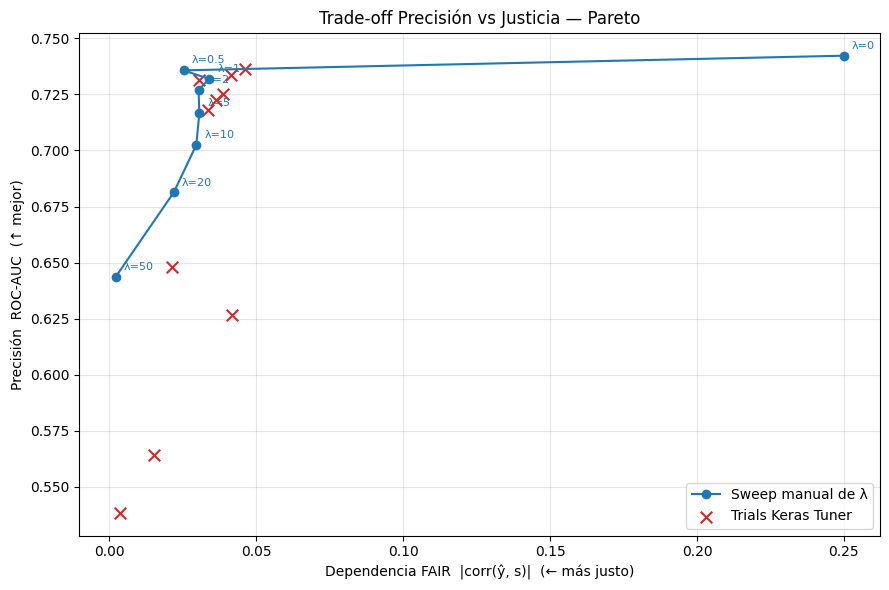

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))

# Sweep manual (línea + puntos anotados)
sw = sweep_df.sort_values("fair_corr")
ax.plot(sweep_df["fair_corr"], sweep_df["roc_auc"], "o-", color="#1f77b4",
        label="Sweep manual de λ", zorder=3)
for _, r in sweep_df.iterrows():
    ax.annotate(f"λ={r['lambda']:g}", (r["fair_corr"], r["roc_auc"]),
                textcoords="offset points", xytext=(6, 5), fontsize=8, color="#1f77b4")

# Nube del Keras Tuner
ax.scatter(tuner_df["fair_corr"], tuner_df["roc_auc"], marker="x", s=70,
           color="#d62728", label="Trials Keras Tuner", zorder=2)

ax.set_xlabel("Dependencia FAIR  |corr(ŷ, s)|  (← más justo)")
ax.set_ylabel("Precisión  ROC-AUC  (↑ mejor)")
ax.set_title("Trade-off Precisión vs Justicia — Pareto")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUTS, "pareto_fairness.png"), dpi=130)
plt.show()

**Comentario (sweep vs tuner)**: el *sweep* manual recorre la frontera de forma
**controlada y uniforme** (cubre desde `λ=0` hasta dependencia ≈0), ideal para
*dibujar* el Pareto. El Keras Tuner, al muestrear `λ` en escala log y optimizar
`val_auc`, **concentra** los trials en la zona de alto AUC (λ pequeños) y explora
menos los λ grandes; es mejor para *encontrar el mejor modelo* bajo un objetivo,
pero peor para mapear toda la frontera. Las celdas siguientes lo verifican
numéricamente.

**Entregable 2** — Curvas de loss (convergencia) del modelo **Base** (`λ=0`) y del
**mejor modelo FAIR**, train vs val.

Definición de **"mejor modelo FAIR"** (criterio explícito): entre los modelos con
`λ>0`, el de **mayor ROC-AUC** sujeto a dependencia `|corr(ŷ, s)| ≤ 0.05`. Si
ninguno cumple el umbral, se toma el de **menor dependencia**.

In [14]:
THRESH_CORR = 0.05

fair_candidates = sweep_df[sweep_df["lambda"] > 0]
ok = fair_candidates[fair_candidates["fair_corr"] <= THRESH_CORR]
if len(ok) > 0:
    best_fair_row = ok.loc[ok["roc_auc"].idxmax()]
    criterio = f"máx ROC-AUC con |corr| ≤ {THRESH_CORR}"
else:
    best_fair_row = fair_candidates.loc[fair_candidates["fair_corr"].idxmin()]
    criterio = "mín |corr| (ningún modelo bajó del umbral)"

best_lambda = float(best_fair_row["lambda"])
print(f"Mejor modelo FAIR: λ={best_lambda:g}  ({criterio})")
print(f"  ROC-AUC={best_fair_row['roc_auc']:.4f}  |corr|={best_fair_row['fair_corr']:.4f}")

Mejor modelo FAIR: λ=0.5  (máx ROC-AUC con |corr| ≤ 0.05)
  ROC-AUC=0.7358  |corr|=0.0253


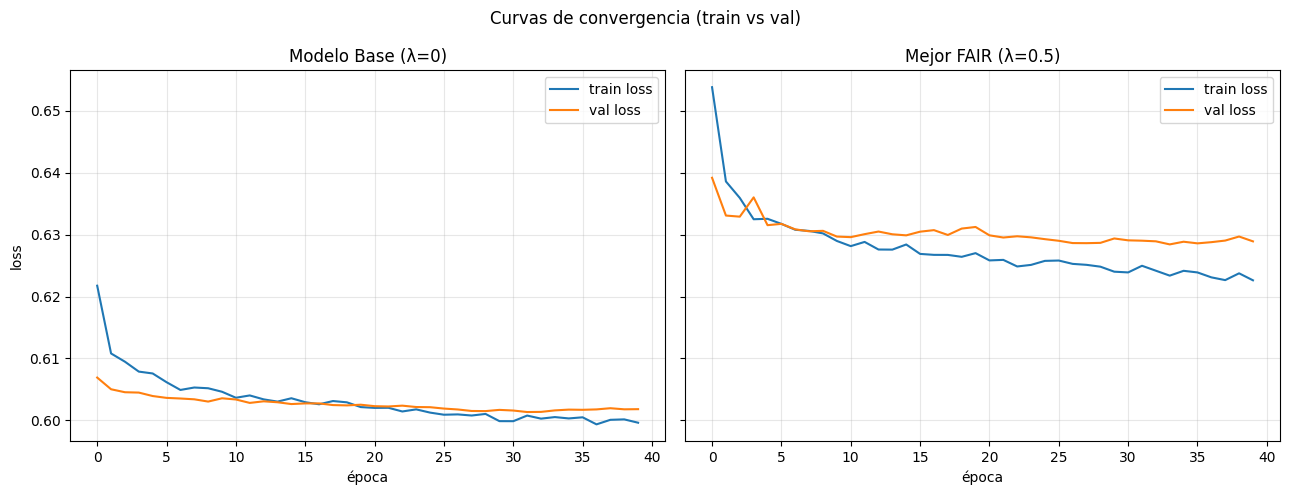

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, lam, titulo in [(axes[0], 0.0, "Modelo Base (λ=0)"),
                        (axes[1], best_lambda, f"Mejor FAIR (λ={best_lambda:g})")]:
    h = histories[lam]
    ax.plot(h["loss"], label="train loss")
    ax.plot(h["val_loss"], label="val loss")
    ax.set_title(titulo)
    ax.set_xlabel("época")
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel("loss")
fig.suptitle("Curvas de convergencia (train vs val)")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUTS, "loss_curves.png"), dpi=130)
plt.show()

## 7. Tabla final Base vs FAIR y conclusiones

**Entregable 3** — Tabla Base (`λ=0`) vs mejor FAIR en test: Accuracy, ROC-AUC,
PR-AUC, `|corr(ŷ, s)|`, Demographic Parity Diff. Se resalta la fila del mejor FAIR.

In [16]:
base_row = sweep_df[sweep_df["lambda"] == 0.0].iloc[0]
bf_row = sweep_df[sweep_df["lambda"] == best_lambda].iloc[0]

tabla = pd.DataFrame([
    {"Modelo": "Base (λ=0)", "Accuracy": base_row["accuracy"], "ROC-AUC": base_row["roc_auc"],
     "PR-AUC": base_row["pr_auc"], "|corr(ŷ,s)|": base_row["fair_corr"], "DPD": base_row["dpd"]},
    {"Modelo": f"Mejor FAIR (λ={best_lambda:g})", "Accuracy": bf_row["accuracy"], "ROC-AUC": bf_row["roc_auc"],
     "PR-AUC": bf_row["pr_auc"], "|corr(ŷ,s)|": bf_row["fair_corr"], "DPD": bf_row["dpd"]},
])
tabla.to_csv(os.path.join(OUTPUTS, "tabla_base_vs_fair.csv"), index=False)

styled = (tabla.style
          .format({"Accuracy": "{:.4f}", "ROC-AUC": "{:.4f}", "PR-AUC": "{:.4f}",
                   "|corr(ŷ,s)|": "{:.4f}", "DPD": "{:.4f}"})
          .apply(lambda r: ["background-color: #d4f7d4" if r["Modelo"].startswith("Mejor FAIR") else "" for _ in r], axis=1)
          .hide(axis="index"))
styled

Modelo,Accuracy,ROC-AUC,PR-AUC,"|corr(ŷ,s)|",DPD
Base (λ=0),0.6840,0.7423,0.2221,0.2499,0.2062
Mejor FAIR (λ=0.5),0.6879,0.7358,0.2139,0.0253,0.0257


**Entregable 4** — ¿Cuánto AUC se sacrifica para llevar la dependencia FAIR a ≈0?

In [17]:
# Modelo "más justo" del sweep (mínima dependencia, típicamente el λ mayor)
fairest = sweep_df.loc[sweep_df["fair_corr"].idxmin()]
auc_base = base_row["roc_auc"]
auc_fairest = fairest["roc_auc"]
auc_best_fair = bf_row["roc_auc"]

print(f"Modelo Base (λ=0):        ROC-AUC={auc_base:.4f}  |corr|={base_row['fair_corr']:.4f}")
print(f"Mejor FAIR (λ={best_lambda:g}):  ROC-AUC={auc_best_fair:.4f}  |corr|={bf_row['fair_corr']:.4f}"
      f"   → sacrificio {(auc_base-auc_best_fair)*100:.2f} pts de AUC")
print(f"Más justo (λ={fairest['lambda']:g}): ROC-AUC={auc_fairest:.4f}  |corr|={fairest['fair_corr']:.4f}"
      f"   → sacrificio {(auc_base-auc_fairest)*100:.2f} pts de AUC")
print()
print(f"RESUMEN: llevar la dependencia FAIR de {base_row['fair_corr']:.3f} a ≈{fairest['fair_corr']:.3f} "
      f"cuesta {(auc_base-auc_fairest)*100:.1f} puntos de ROC-AUC.")

Modelo Base (λ=0):        ROC-AUC=0.7423  |corr|=0.2499
Mejor FAIR (λ=0.5):  ROC-AUC=0.7358  |corr|=0.0253   → sacrificio 0.65 pts de AUC
Más justo (λ=50): ROC-AUC=0.6436  |corr|=0.0021   → sacrificio 9.87 pts de AUC

RESUMEN: llevar la dependencia FAIR de 0.250 a ≈0.002 cuesta 9.9 puntos de ROC-AUC.


### Conclusiones

- La **FAIR loss** funciona: al aumentar `λ`, la dependencia `|corr(ŷ, s)|` y la
  **Demographic Parity Difference** caen de forma monótona, confirmando que la
  penalización suprime la influencia del género en la predicción.
- Existe un **trade-off claro precisión × justicia**: la práctica anulación de la
  dependencia se paga con una caída de ROC-AUC (ver entregable 4). El **mejor modelo
  FAIR** (criterio: máx AUC con `|corr| ≤ 0.05`) ofrece un punto de equilibrio
  razonable: justicia casi total con un sacrificio acotado de precisión.
- El **sweep manual** mapea mejor toda la frontera de Pareto; el **Keras Tuner**
  (objetivo `val_auc`) es más eficaz para localizar el mejor modelo pero sesga el
  muestreo hacia `λ` pequeños (alta precisión, menos justicia).
- Mantener `CODE_GENDER` en la entrada y dejar que la **FAIR loss** lo neutralice
  evita el sesgo sin recurrir a *fairness through unawareness*, preservando la
  comparación *apples-to-apples* con el modelo base.